A exploratory data analysis pipeline that automatically detects column types and performs statistical summaries, missing value analysis, numeric and categorical distributions, correlation analysis, and time-based trend exploration for any uploaded CSV dataset.


Cell 1 —Installs required libraries
This sets up the EDA environment. Without this, nothing else runs.



In [ ]:
!pip -q install pandas numpy matplotlib

import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files


Cell 2 — Upload CSV (browser upload)
A table showing the first 5 rows of your dataset

In [ ]:
uploaded = files.upload()

if len(uploaded) == 0:
    raise ValueError("No file uploaded. Please upload a CSV file.")

filename = list(uploaded.keys())[0]
# Attempt to read with 'utf-8', if it fails, try 'latin1'
try:
    df = pd.read_csv(io.BytesIO(uploaded[filename]))
except UnicodeDecodeError:
    df = pd.read_csv(io.BytesIO(uploaded[filename]), encoding='latin1')

print("Loaded file:", filename)
df.head()

Saving OnlineRetail.csv to OnlineRetail (1).csv
Loaded file: OnlineRetail (1).csv


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


Cell 3 — EDA helper functions
1)detect_column_types(df) like numeric columns,categorical columns,datetime-like columns


2)basic_overview(df) shows shape (rows × columns),column names, types & null counts (df.info()),first few rows,numeric summary statistics (describe())
This answers:How big is the dataset?
What kind of data do we have?

3)missing_and_duplicates(df)-Calculates missing values per column,Shows missing percentage,Counts duplicate rows


4)numeric_eda(df, numeric_cols)-For numeric columns:summary statistics table,histograms (distribution),boxplots (outliers),correlation heatmap
This helps us to understand:distributions (skewed, normal, etc.)outliers,relationships between variables

5)categorical_eda(df, cat_cols)-For categorical columns:shows top values and counts,bar charts for frequency distribution
This shows:dominant categories,imbalance,rare values
Very important for classification, segmentation, dashboards.

6)datetime_eda(df, datetime_cols)-For datetime columns:parses dates safely,plots frequency over time.
Time-based datasets need trend analysis:seasonality,spikes,gaps in data

In [ ]:
def detect_column_types(df: pd.DataFrame):
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()

    # Try parsing datetime for object columns (light attempt)
    datetime_cols = []
    for c in df.select_dtypes(include=["object"]).columns:
        sample = df[c].dropna().astype(str).head(50)
        if len(sample) == 0:
            continue
        parsed = pd.to_datetime(sample, errors="coerce", infer_datetime_format=True)
        if parsed.notna().mean() >= 0.8:
            datetime_cols.append(c)

    # Category/string columns excluding detected datetime
    cat_cols = [c for c in df.columns if c not in numeric_cols and c not in datetime_cols]
    return numeric_cols, cat_cols, datetime_cols


def basic_overview(df: pd.DataFrame):
    print("==== BASIC OVERVIEW ====")
    print("Shape (rows, cols):", df.shape)
    print("\nColumns:", df.columns.tolist())

    print("\n==== INFO ====")
    display(df.info())

    print("\n==== HEAD (5) ====")
    display(df.head())

    print("\n==== DESCRIBE (NUMERIC) ====")
    if df.select_dtypes(include=["number"]).shape[1] > 0:
        display(df.describe().T)
    else:
        print("No numeric columns found.")


def missing_and_duplicates(df: pd.DataFrame):
    print("\n==== MISSING VALUES ====")
    miss = df.isna().sum()
    miss_pct = (miss / len(df) * 100).round(2)
    miss_tbl = pd.DataFrame({"missing_count": miss, "missing_pct": miss_pct})
    miss_tbl = miss_tbl[miss_tbl["missing_count"] > 0].sort_values("missing_count", ascending=False)
    if len(miss_tbl) == 0:
        print("No missing values found.")
    else:
        display(miss_tbl)

    print("\n==== DUPLICATE ROWS ====")
    dup_count = int(df.duplicated().sum())
    print("Duplicate rows:", dup_count)


def numeric_eda(df: pd.DataFrame, numeric_cols: list, max_cols: int = 8):
    if len(numeric_cols) == 0:
        print("\nNo numeric columns for numeric EDA.")
        return

    cols = numeric_cols[:max_cols]
    print(f"\n==== NUMERIC EDA (showing up to {max_cols} columns) ====")
    display(df[cols].describe().T)

    # Histograms
    for c in cols:
        plt.figure()
        df[c].dropna().hist(bins=30)
        plt.title(f"Histogram: {c}")
        plt.xlabel(c)
        plt.ylabel("Frequency")
        plt.show()

    # Boxplots
    for c in cols:
        plt.figure()
        plt.boxplot(df[c].dropna(), vert=True)
        plt.title(f"Boxplot: {c}")
        plt.ylabel(c)
        plt.show()

    # Correlation heatmap (numeric only)
    if len(cols) >= 2:
        corr = df[cols].corr(numeric_only=True)
        plt.figure(figsize=(8, 6))
        plt.imshow(corr, aspect="auto")
        plt.title("Correlation Heatmap (numeric columns)")
        plt.xticks(range(len(cols)), cols, rotation=90)
        plt.yticks(range(len(cols)), cols)
        plt.colorbar()
        plt.tight_layout()
        plt.show()


def categorical_eda(df: pd.DataFrame, cat_cols: list, top_k: int = 10, max_cols: int = 6):
    if len(cat_cols) == 0:
        print("\nNo categorical columns for categorical EDA.")
        return

    cols = cat_cols[:max_cols]
    print(f"\n==== CATEGORICAL EDA (showing up to {max_cols} columns) ====")

    for c in cols:
        vc = df[c].astype(str).value_counts(dropna=False).head(top_k)
        display(pd.DataFrame({c: vc.index, "count": vc.values}))

        plt.figure()
        plt.bar(vc.index.astype(str), vc.values)
        plt.title(f"Top {top_k} values: {c}")
        plt.xticks(rotation=90)
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()


def datetime_eda(df: pd.DataFrame, datetime_cols: list, max_cols: int = 2):
    if len(datetime_cols) == 0:
        print("\nNo datetime-like columns detected.")
        return

    cols = datetime_cols[:max_cols]
    print(f"\n==== DATETIME EDA (showing up to {max_cols} columns) ====")

    for c in cols:
        dt = pd.to_datetime(df[c], errors="coerce", infer_datetime_format=True)
        tmp = pd.DataFrame({"dt": dt}).dropna()

        if tmp.empty:
            print(f"{c}: could not parse any valid dates.")
            continue

        # counts per day (simple time distribution)
        counts = tmp["dt"].dt.date.value_counts().sort_index()

        plt.figure(figsize=(10, 4))
        plt.plot(counts.index.astype(str), counts.values)
        plt.title(f"Date frequency over time: {c}")
        plt.xticks(rotation=90)
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()


Cell 4 — Run full EDA
Automatically detects column types,Runs all EDA steps in order,Prints final report

/tmp/ipython-input-1492139538.py:10: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  parsed = pd.to_datetime(sample, errors="coerce", infer_datetime_format=True)
/tmp/ipython-input-1492139538.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(sample, errors="coerce", infer_datetime_format=True)
/tmp/ipython-input-1492139538.py:10: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  parsed = pd.to_date

==== BASIC OVERVIEW ====
Shape (rows, cols): (541909, 8)

Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

==== INFO ====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


None


==== HEAD (5) ====


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


...

,count,mean,std,min,25%,50%,75%,max
Quantity,541909.0,9.552250,218.081158,-80995.00,1.00,3.00,10.00,80995.0
UnitPrice,541909.0,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,15287.690570,1713.600303,12346.00,13953.00,15152.00,16791.00,18287.0



==== MISSING VALUES ====


,missing_count,missing_pct
CustomerID,135080,24.93
Description,1454,0.27



==== DUPLICATE ROWS ====
Duplicate rows: 5268

==== NUMERIC EDA (showing up to 8 columns) ====


,count,mean,std,min,25%,50%,75%,max
Quantity,541909.0,9.552250,218.081158,-80995.00,1.00,3.00,10.00,80995.0
UnitPrice,541909.0,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,15287.690570,1713.600303,12346.00,13953.00,15152.00,16791.00,18287.0


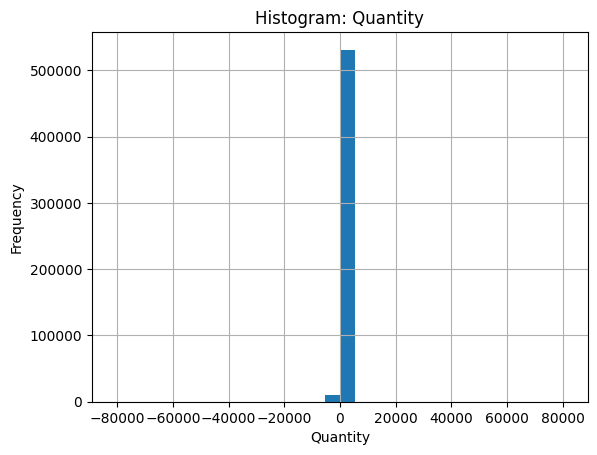

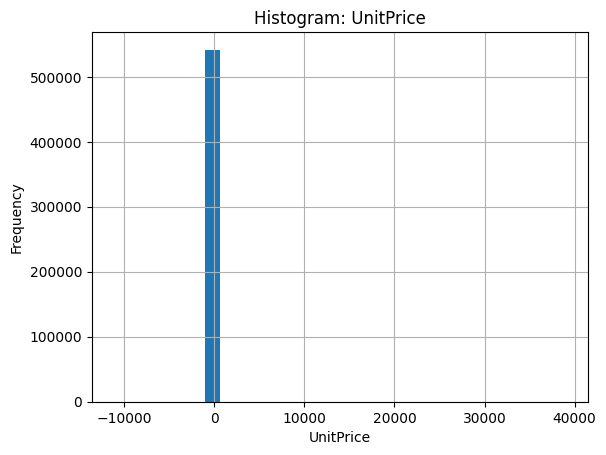

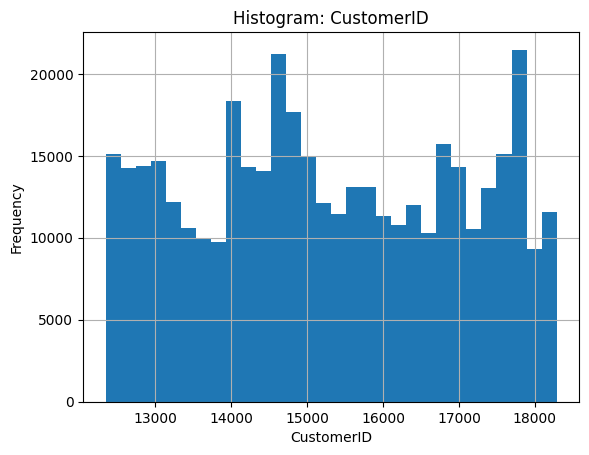

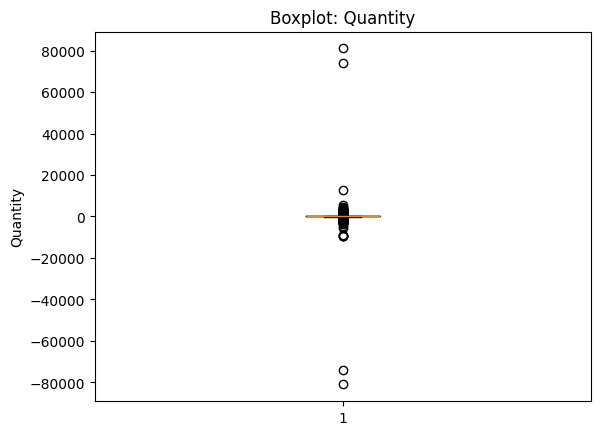

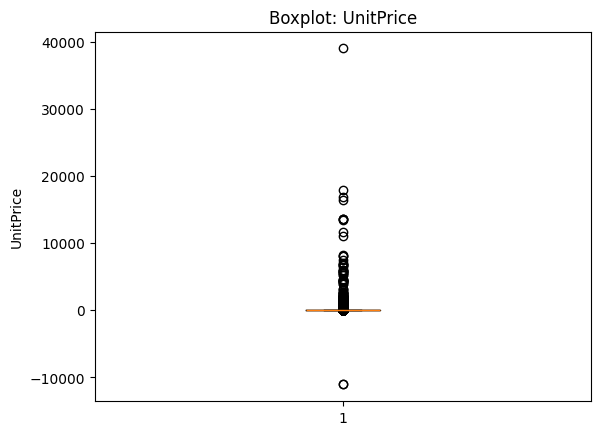

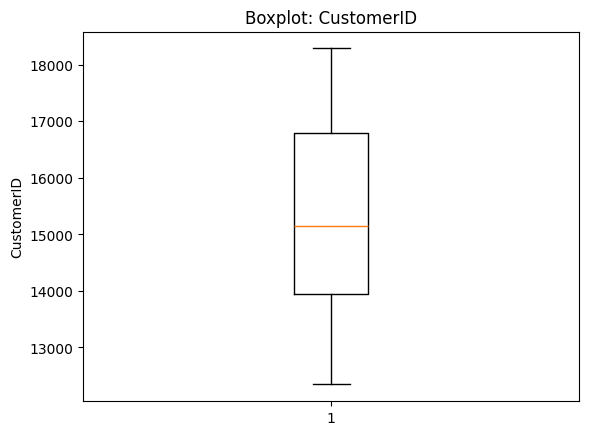

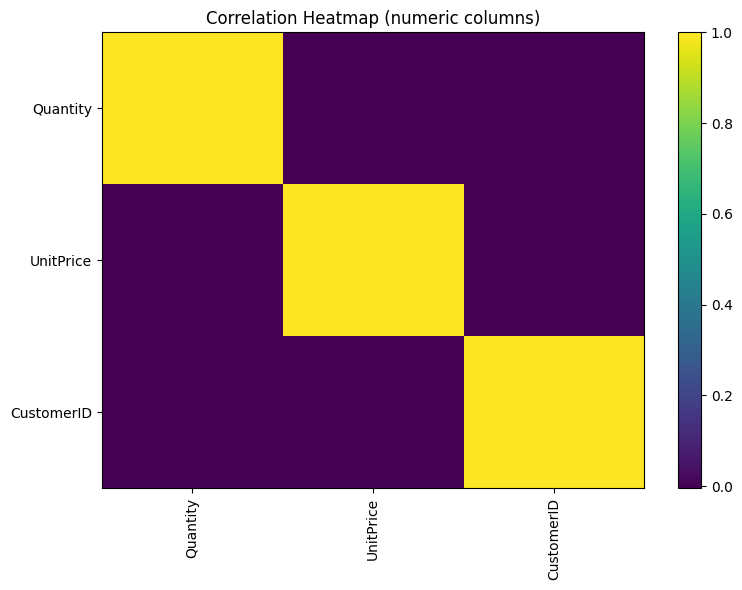


==== CATEGORICAL EDA (showing up to 6 columns) ====


,InvoiceNo,count
0,573585,1114
1,581219,749
2,581492,731
3,580729,721
4,558475,705
5,579777,687
6,581217,676
7,537434,675
8,580730,662
9,538071,652


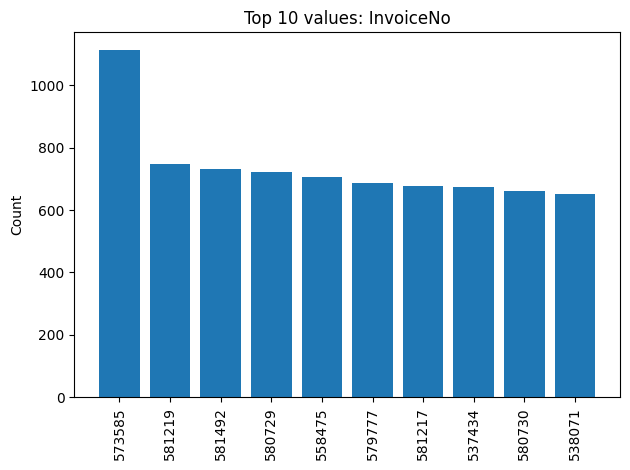

,StockCode,count
0,85123A,2313
1,22423,2203
2,85099B,2159
3,47566,1727
4,20725,1639
5,84879,1502
6,22720,1477
7,22197,1476
8,21212,1385
9,20727,1350


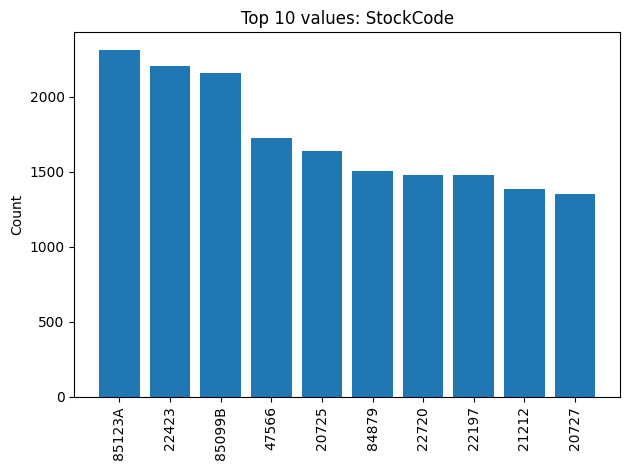

,Description,count
0,WHITE HANGING HEART T-LIGHT HOLDER,2369
1,REGENCY CAKESTAND 3 TIER,2200
2,JUMBO BAG RED RETROSPOT,2159
3,PARTY BUNTING,1727
4,LUNCH BAG RED RETROSPOT,1638
5,ASSORTED COLOUR BIRD ORNAMENT,1501
6,SET OF 3 CAKE TINS PANTRY DESIGN,1473
7,nan,1454
8,PACK OF 72 RETROSPOT CAKE CASES,1385
9,LUNCH BAG BLACK SKULL.,1350


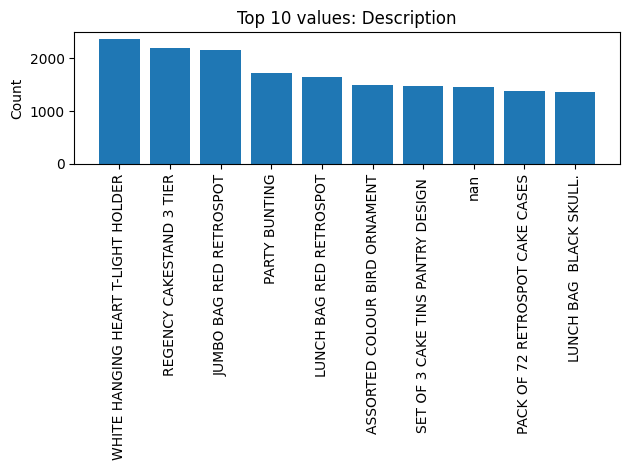

,Country,count
0,United Kingdom,495478
1,Germany,9495
2,France,8557
3,EIRE,8196
4,Spain,2533
5,Netherlands,2371
6,Belgium,2069
7,Switzerland,2002
8,Portugal,1519
9,Australia,1259


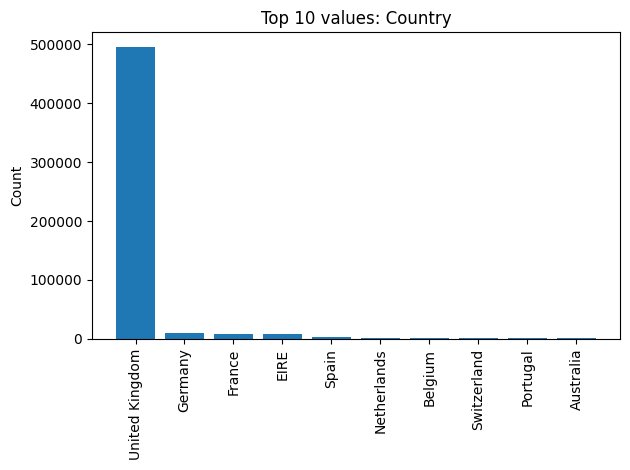


==== DATETIME EDA (showing up to 2 columns) ====


/tmp/ipython-input-1492139538.py:122: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt = pd.to_datetime(df[c], errors="coerce", infer_datetime_format=True)


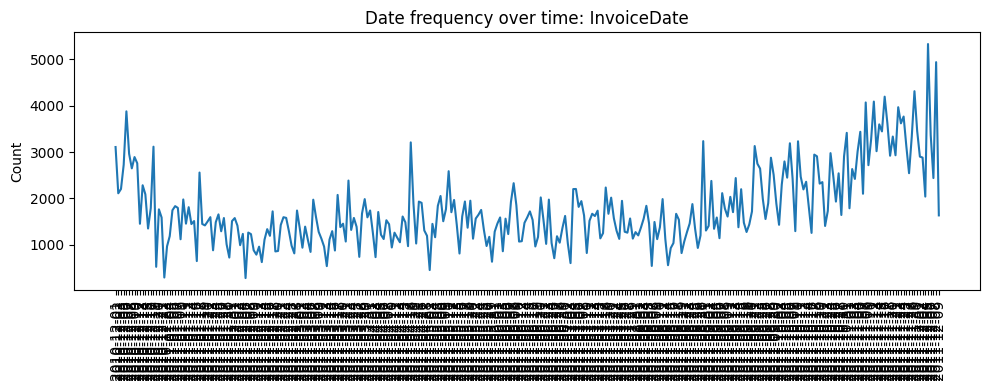


==== COLUMN TYPE SUMMARY ====
Numeric columns: ['Quantity', 'UnitPrice', 'CustomerID']
Categorical columns: ['InvoiceNo', 'StockCode', 'Description', 'Country']
Datetime-like columns: ['InvoiceDate']


In [ ]:
numeric_cols, cat_cols, datetime_cols = detect_column_types(df)

basic_overview(df)
missing_and_duplicates(df)

numeric_eda(df, numeric_cols, max_cols=8)
categorical_eda(df, cat_cols, top_k=10, max_cols=6)
datetime_eda(df, datetime_cols, max_cols=2)

print("\n==== COLUMN TYPE SUMMARY ====")
print("Numeric columns:", numeric_cols)
print("Categorical columns:", cat_cols)
print("Datetime-like columns:", datetime_cols)
